
**Real Data**: Empirical hypergraph datasets
**Original ES**: original es-based generation
**SR-based Improved**: improved approach based on simplicial ratio methodology

**Outline**
- Extract the giant component
- Calculate simpliciality measures (ES, SF, FES)
- Generate hypergraphs using both methods with matching parameters
- Compare giant component growth patterns
- Compare achieved simpliciality measures


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import xgi
import sys
import os
import hypercontagion as hc

sys.path.append('.')
sys.path.append('./edge_rewiring')
sys.path.append('./Simplicial_Ratio')
sys.path.append('./Simplicial_Ratio/Experiments')

from edge_rewiring.model_generation import model_generation_es, model_generation_es_sr_improved
from sod.simpliciality import edit_simpliciality, face_edit_simpliciality, simplicial_fraction

from Simplicial_Ratio.utils import giant_component
from Simplicial_Ratio.Experiments.Hypergraph_Processes import giant_component_growth


## parameter estimation


In [ ]:
def improved_(parameter_estimationV_real, E_real, es_real):

    n_real = len(V_real)
    m_real = len(E_real)
    
    # Create temporary hypergraph to analyze structure
    H_temp = xgi.Hypergraph()
    H_temp.add_nodes_from(V_real)
    H_temp.add_edges_from(E_real)
    
    # Count maximal hyperedges
    maximal_edges = H_temp.edges.maximal()
    num_maximal = len(maximal_edges)
    
    # Better estimation of C_total
    # ES = |E| / (|E| + missing_subfaces)
    # missing_subfaces = |E| * (1 - ES) / ES
    # C_total = |E| + missing_subfaces = |E| / ES
    if es_real > 0:
        C_total_estimate = int(m_real / es_real)
    else:
        C_total_estimate = m_real * 2
    
    # Ensure C_total is reasonable (not too large)
    max_reasonable_C = n_real * (n_real - 1) // 2  # Maximum possible edges
    C_total_estimate = min(C_total_estimate, max_reasonable_C)
    
    # Ensure we have enough maximal hyperedges
    min_maximal = max(1, int(m_real * 0.1))  # At least 10% should be maximal
    num_maximal = max(num_maximal, min_maximal)
    
    return C_total_estimate, num_maximal


## Load datasets


In [ ]:
# Set random seed for reproducibility
random.seed(321)
np.random.seed(321)

# List of datasets to compare
datasets_list = [
    "contact-high-school",
    "hospital-lyon",
    "contact-primary-school",
    "email-enron",
]

# Load and prepare datasets
datasets = {}
simpliciality_data = {}

for filename in datasets_list:
    print(f"Loading {filename}...")
    try:
        H = xgi.load_xgi_data(filename)
        H.cleanup(connected=True,relabel=False)
        # Filter edges by size (2 to 11)
        E = list(set([tuple(sorted(e)) for e in H.edges.members() if len(e) >= 2]))
        E = [set(e) for e in E]  # Convert to list of sets for giant_component
        V = list(set([i for e in E for i in e]))
        
        # Extract giant component (returns V, E)
        V, E = giant_component(V, E)
        E = [list(e) for e in E]  # Convert back to list of lists for xgi
        
        datasets[filename] = (V, E)
        
        # Calculate simpliciality measures
        H_clean = xgi.Hypergraph()
        H_clean.add_nodes_from(V)
        H_clean.add_edges_from(E)
        
        simpliciality_data[filename] = {
            'sf': simplicial_fraction(H_clean, min_size=2),
            'es': edit_simpliciality(H_clean, min_size=2),
            'fes': face_edit_simpliciality(H_clean, min_size=2)
        }
        
        print(f"  |V| = {len(V)}, |E| = {len(E)}")
        print(f"  SF = {simpliciality_data[filename]['sf']:.3f}, "
              f"ES = {simpliciality_data[filename]['es']:.3f}, "
              f"FES = {simpliciality_data[filename]['fes']:.3f}")
    except Exception as e:
        print(f"  Error loading {filename}: {e}")
        continue


Loading contact-high-school...
  |V| = 327, |E| = 7818
  SF = 0.806, ES = 0.927, FES = 0.923
Loading hospital-lyon...
  |V| = 75, |E| = 1824
  SF = 0.912, ES = 0.954, FES = 0.972
Loading contact-primary-school...
  |V| = 242, |E| = 12704
  SF = 0.847, ES = 0.918, FES = 0.937
Loading email-enron...
  |V| = 143, |E| = 1442
  SF = 0.313, ES = 0.052, FES = 0.498


## Generate Models and Compare


In [4]:
# Store results for all datasets
comparison_results = {}

for dataset_name in datasets.keys():
    print(f"\n{'='*80}")
    print(f"Processing {dataset_name}")
    print(f"{'='*80}")
    
    V_real, E_real = datasets[dataset_name]
    n_real = len(V_real)
    m_real = len(E_real)
    es_real = simpliciality_data[dataset_name]['es']
    
    print(f"Real data: n={n_real}, m={m_real}, ES={es_real:.3f}")
    
    # Method 1: Original model_generation_es
    # print("\n--- Method 1: Original model_generation_es ---")
    # try:
    #     C_estimate, num_maximal = improved_parameter_estimation(V_real, E_real, es_real)
    #     print(f"Estimated parameters: C_total={C_estimate}, num_maximal={num_maximal}")
        
    #     H_original = model_generation_es(
    #         es=es_real,
    #         approx_num_C=C_estimate,
    #         num_max_hyperedge=num_maximal,
    #         num_node=n_real,
    #         min_size=2,
    #         max_size=None,
    #         adjust_es=False
    #     )
        
    #     E_original = [list(edge) for edge in H_original.edges.members()]
    #     V_original = list(H_original.nodes)
        
    #     es_original = edit_simpliciality(H_original, min_size=2)
    #     sf_original = simplicial_fraction(H_original, min_size=2)
    #     fes_original = face_edit_simpliciality(H_original, min_size=2)
        
    #     print(f"Generated: n={H_original.num_nodes}, m={H_original.num_edges}")
    #     print(f"ES={es_original:.3f}, SF={sf_original:.3f}, FES={fes_original:.3f}")
        
    #     original_success = True
    # except Exception as e:
    #     print(f"Error with original method: {e}")
    #     H_original = None
    #     E_original = None
    #     V_original = None
    #     es_original = None
    #     sf_original = None
    #     fes_original = None
    #     original_success = False
    
    # Method 2: SR-based improved
    print("\n--- Method 2: SR-based Improved ---")
    try:
        H1 = xgi.load_xgi_data(dataset_name)
        H1.cleanup(connected=True,relabel=False)
        tmp = H1.edges.maximal().members()
        maximal_edge_sizes = [len(e) for e in tmp]
        H_sr = model_generation_es_sr_improved(
            target_es=es_real,
            num_nodes=n_real,
            num_edges=m_real,
            min_size=2,
            max_size=max(maximal_edge_sizes),
            maximal_edge_sizes=maximal_edge_sizes
        )
        
        E_sr = [list(edge) for edge in H_sr.edges.members()]
        V_sr = list(H_sr.nodes)
        
        es_sr = edit_simpliciality(H_sr, min_size=2)
        sf_sr = simplicial_fraction(H_sr, min_size=2)
        fes_sr = face_edit_simpliciality(H_sr, min_size=2)
        
        print(f"Generated: n={H_sr.num_nodes}, m={H_sr.num_edges}")
        print(f"ES={es_sr:.3f}, SF={sf_sr:.3f}, FES={fes_sr:.3f}")
        
        sr_success = True
    except Exception as e:
        print(f"Error with SR-based method: {e}")
        H_sr = None
        E_sr = None
        V_sr = None
        es_sr = None
        sf_sr = None
        fes_sr = None
        sr_success = False
    
    # Store results
    comparison_results[dataset_name] = {
        'real': {
            'V': V_real,
            'E': E_real,
            'n': n_real,
            'm': m_real,
            'es': es_real,
            'sf': simpliciality_data[dataset_name]['sf'],
            'fes': simpliciality_data[dataset_name]['fes']
        },
        # 'original': {
        #     'H': H_original,
        #     'V': V_original,
        #     'E': E_original,
        #     'n': H_original.num_nodes if H_original else None,
        #     'm': H_original.num_edges if H_original else None,
        #     'es': es_original,
        #     'sf': sf_original,
        #     'fes': fes_original,
        #     'success': original_success
        # },
        'sr_improved': {
            'H': H_sr,
            'V': V_sr,
            'E': E_sr,
            'n': H_sr.num_nodes if H_sr else None,
            'm': H_sr.num_edges if H_sr else None,
            'es': es_sr,
            'sf': sf_sr,
            'fes': fes_sr,
            'success': sr_success
        }
    }



Processing contact-high-school
Real data: n=327, m=7818, ES=0.927

--- Method 2: SR-based Improved ---
Current ES: 1.000, Target: 0.927
Generated: n=327, m=7818
ES=0.861, SF=0.272, FES=0.729

Processing hospital-lyon
Real data: n=75, m=1824, ES=0.954

--- Method 2: SR-based Improved ---
Current ES: 1.000, Target: 0.954
Generated: n=75, m=1824
ES=0.912, SF=0.587, FES=0.855

Processing contact-primary-school
Real data: n=242, m=12704, ES=0.918

--- Method 2: SR-based Improved ---
Current ES: 1.000, Target: 0.918
Generated: n=242, m=12704
ES=0.886, SF=0.447, FES=0.797

Processing email-enron
Real data: n=143, m=1442, ES=0.052

--- Method 2: SR-based Improved ---
Current ES: 0.000, Target: 0.052
Generated: n=143, m=1442
ES=0.746, SF=0.000, FES=0.128


## Compare Giant Component Growth


In [5]:
# Compute giant component growth for each method with multiple runs for error bands
num_runs = 5  # Number of runs for error band calculation

for dataset_name in comparison_results.keys():
    print(f"\nComputing giant component growth for {dataset_name}...")
    
    real_data = comparison_results[dataset_name]['real']
    # original_data = comparison_results[dataset_name]['original']
    sr_data = comparison_results[dataset_name]['sr_improved']
    
    # Real data - single run (no error bands needed for real data)
    if real_data['E']:
        E_real_sets = [set(e) for e in real_data['E']]
        real_growth = giant_component_growth(real_data['V'], E_real_sets)
        comparison_results[dataset_name]['real']['growth'] = real_growth
    
    # Original method - multiple runs for error bands
    # if original_data['success'] and original_data['E']:
    #     original_growths = []
    #     for run in range(num_runs):
    #         E_original_sets = [set(e) for e in original_data['E']]
    #         growth = giant_component_growth(original_data['V'], E_original_sets)
    #         original_growths.append(growth)
    #     comparison_results[dataset_name]['original']['growths'] = original_growths
    
    # SR-based improved - multiple runs for error bands
    if sr_data['success'] and sr_data['E']:
        sr_growths = []
        for run in range(num_runs):
            E_sr_sets = [set(e) for e in sr_data['E']]
            growth = giant_component_growth(sr_data['V'], E_sr_sets)
            sr_growths.append(growth)
        comparison_results[dataset_name]['sr_improved']['growths'] = sr_growths



Computing giant component growth for contact-high-school...

Computing giant component growth for hospital-lyon...

Computing giant component growth for contact-primary-school...

Computing giant component growth for email-enron...


## Visualize Results


NameError: name 'original_data' is not defined

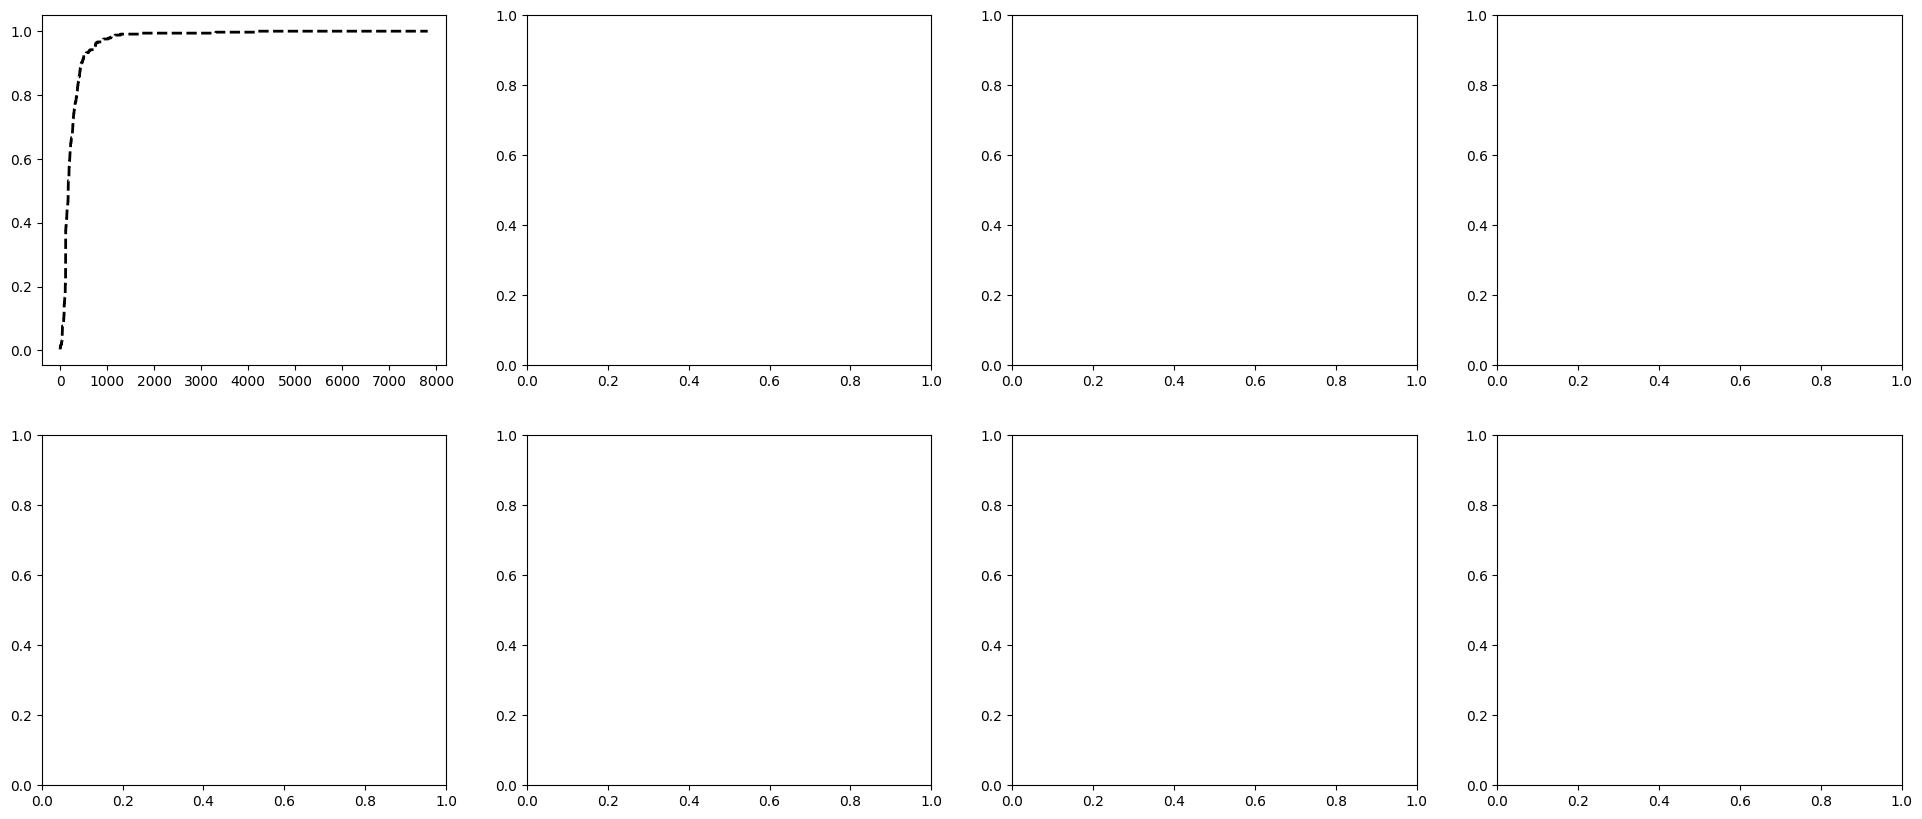

In [6]:
# Create comparison plots with error bands for each dataset
num_datasets = len(comparison_results)
fig, axes = plt.subplots(2, num_datasets, figsize=(6*num_datasets, 10))

if num_datasets == 1:
    axes = axes.reshape(2, 1)

for idx, dataset_name in enumerate(comparison_results.keys()):
    real_data = comparison_results[dataset_name]['real']
     
    sr_data = comparison_results[dataset_name]['sr_improved']
    
    n = real_data['n']
    
    # Plot 1: Giant Component Growth with Error Bands
    ax1 = axes[0, idx]
    
    # Real data (single line, no error bands)
    if 'growth' in real_data:
        keys = sorted(real_data['growth'].keys())
        values = [real_data['growth'][k]/n for k in keys]
        ax1.plot(keys, values, label='Real Data', color='black', linewidth=2, linestyle='--')
    
    # Original method with error bands
    if original_data['success'] and 'growths' in original_data:
        growths = original_data['growths']
        # Get common keys
        all_keys = set()
        for growth in growths:
            all_keys.update(growth.keys())
        keys = sorted(all_keys)
        
        # Calculate mean and std for each key
        values_list = []
        for k in keys:
            vals = [growth.get(k, 0)/n for growth in growths]
            values_list.append(vals)
        
        means = [np.mean(vals) for vals in values_list]
        stds = [np.std(vals) for vals in values_list]
        
        ax1.plot(keys, means, label='Original ES (mean)', color='blue', linewidth=2)
        ax1.fill_between(keys, 
                         np.array(means) - np.array(stds),
                         np.array(means) + np.array(stds),
                         color='blue', alpha=0.3)
    
    # SR-based improved with error bands
    if sr_data['success'] and 'growths' in sr_data:
        growths = sr_data['growths']
        # Get common keys
        all_keys = set()
        for growth in growths:
            all_keys.update(growth.keys())
        keys = sorted(all_keys)
        
        # Calculate mean and std for each key
        values_list = []
        for k in keys:
            vals = [growth.get(k, 0)/n for growth in growths]
            values_list.append(vals)
        
        means = [np.mean(vals) for vals in values_list]
        stds = [np.std(vals) for vals in values_list]
        
        ax1.plot(keys, means, label='SR-based Improved (mean)', color='red', linewidth=2)
        ax1.fill_between(keys,
                         np.array(means) - np.array(stds),
                         np.array(means) + np.array(stds),
                         color='red', alpha=0.3)
    
    ax1.set_title(f'{dataset_name}\nES={real_data["es"]:.3f}', fontsize=12)
    ax1.set_xlabel('Number of edges added')
    ax1.set_ylabel('Normalized giant component size')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Plot 2: Simpliciality Measures Comparison
    ax2 = axes[1, idx]
    
    methods = ['Real', 'Original', 'SR-based']
    es_values = [real_data['es'], original_data['es'] if original_data['success'] else 0, 
                 sr_data['es'] if sr_data['success'] else 0]
    sf_values = [real_data['sf'], original_data['sf'] if original_data['success'] else 0,
                 sr_data['sf'] if sr_data['success'] else 0]
    
    x = np.arange(len(methods))
    width = 0.35
    
    ax2.bar(x - width/2, es_values, width, label='Edit Simpliciality (ES)', alpha=0.8)
    ax2.bar(x + width/2, sf_values, width, label='Simplicial Fraction (SF)', alpha=0.8)
    
    ax2.set_title('Simpliciality Measures')
    ax2.set_ylabel('Value')
    ax2.set_xticks(x)
    ax2.set_xticklabels(methods, rotation=45)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('model_comparison_results.png', dpi=300, bbox_inches='tight')
plt.show()


## Summary Table


In [ ]:
# Create summary table
summary_data = []

for dataset_name in comparison_results.keys():
    real_data = comparison_results[dataset_name]['real']
    # original_data = comparison_results[dataset_name]['original']
    sr_data = comparison_results[dataset_name]['sr_improved']
    
    # Calculate ES errors
    # original_es_error = abs(original_data['es'] - real_data['es']) if original_data['success'] else None
    sr_es_error = abs(sr_data['es'] - real_data['es']) if sr_data['success'] else None
    
    summary_data.append({
        'Dataset': dataset_name,
        'Real ES': f"{real_data['es']:.3f}",
        # 'Original ES': f"{original_data['es']:.3f}" if original_data['success'] else 'N/A',
        # 'Original Error': f"{original_es_error:.3f}" if original_es_error is not None else 'N/A',
        'SR-based ES': f"{sr_data['es']:.3f}" if sr_data['success'] else 'N/A',
        'SR-based Error': f"{sr_es_error:.3f}" if sr_es_error is not None else 'N/A',
        # 'Original Success': 'Yes' if original_data['success'] else 'No',
        'SR Success': 'Yes' if sr_data['success'] else 'No'
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*100)
print("SUMMARY COMPARISON")
print("="*100)
print(summary_df.to_string(index=False))

# Calculate average errors
# original_errors = [abs(comparison_results[d]['original']['es'] - comparison_results[d]['real']['es']) 
#                    for d in comparison_results.keys() 
#                    if comparison_results[d]['original']['success']]
sr_errors = [abs(comparison_results[d]['sr_improved']['es'] - comparison_results[d]['real']['es']) 
             for d in comparison_results.keys() 
             if comparison_results[d]['sr_improved']['success']]

# if original_errors:
#     print(f"\nAverage Original ES Error: {np.mean(original_errors):.3f} ± {np.std(original_errors):.3f}")
if sr_errors:
    print(f"Average SR-based ES Error: {np.mean(sr_errors):.3f} ± {np.std(sr_errors):.3f}")



SUMMARY COMPARISON
               Dataset Real ES SR-based ES SR-based Error SR Success
   contact-high-school   0.927       0.861          0.066        Yes
         hospital-lyon   0.954       0.912          0.043        Yes
contact-primary-school   0.918       0.886          0.032        Yes
           email-enron   0.052       0.785          0.733        Yes
Average SR-based ES Error: 0.218 ± 0.297


## SIR Comparison with Error Bands

Compare SIR dynamics on original model vs SR-based improved model with error bands.


In [ ]:
# Run SIR comparison for each dataset with multiple gamma values
num_sir_runs = 3
gamma_values = [0.05, 0.1, 0.2, 0.4, 0.6, 0.8]
colors_real = ["#00B388", "#DA291C", "#418FDF"]  # Colors for real data (S, I, R)
colors_original = ["#0066CC", "#FF3333", "#6600CC"]  # Colors for Original method (S, I, R)
colors_sr = ["#00CC66", "#FF6600", "#0066FF"]  # Colors for SR-based method (S, I, R)

for dataset_name in comparison_results.keys():
    print(f"\n{'='*80}")
    print(f"Running SIR comparison for {dataset_name}")
    print(f"{'='*80}")
    
    real_data = comparison_results[dataset_name]['real']
    n_real = real_data['n']
    m_real = real_data['m']
    es_real = real_data['es']
    
    # Generate graphs for each method
    print("Generating graphs for Original method...")
    H_original_list = []
    for run in range(num_sir_runs):
        try:
            C_estimate, num_maximal = improved_parameter_estimation(real_data['V'], real_data['E'], es_real)
            H = model_generation_es(
                es=es_real,
                approx_num_C=C_estimate,
                num_max_hyperedge=num_maximal,
                num_node=n_real,
                min_size=2,
                max_size=None,
                adjust_es=False
            )
            H_original_list.append(H)
        except Exception as e:
            print(f"  Error in run {run+1}: {e}")
            continue
    
    print("Generating graphs for SR-based Improved method...")
    H_sr_list = []
    for run in range(num_sir_runs):
        try:
            H1 = xgi.load_xgi_data("email-enron")
            H1.cleanup(connected=True,relabel=False)
            tmp = H1.edges.maximal().members()
            maximal_edge_sizes = [len(e) for e in tmp]
            H = model_generation_es_sr_improved(
                target_es=es_real,
                num_nodes=n_real,
                num_edges=m_real,
                min_size=2,
                max_size=None,
                maximal_edge_sizes=maximal_edge_sizes
            )
            H_sr_list.append(H)
        except Exception as e:
            print(f"  Error in run {run+1}: {e}")
            continue
    
    # Prepare real data
    H_real = xgi.Hypergraph()
    H_real.add_nodes_from(real_data['V'])
    H_real.add_edges_from(real_data['E'])
    tau_real = {k: 0.1/k for k in xgi.unique_edge_sizes(H_real)}
    
    # Create subplots for each gamma
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, gamma in enumerate(gamma_values):
        ax = axes[idx]
        
        # Real data
        t_real, S_real, I_real, R_real = hc.discrete_SIR(H_real, tau_real, gamma=gamma, rho=0.1, tmin=0, tmax=100, dt=1)
        ax.plot(t_real, S_real / n_real, color=colors_real[0], label="S (real)", linestyle='--')
        ax.plot(t_real, I_real / n_real, color=colors_real[1], label="I (real)", linestyle='--')
        ax.plot(t_real, R_real / n_real, color=colors_real[2], label="R (real)", linestyle='--')
        
        # Original method with error bands
        if len(H_original_list) > 0:
            S_all, I_all, R_all = [], [], []
            t_vals = None
            
            for H in H_original_list:
                tau = {k: 0.1/k for k in xgi.unique_edge_sizes(H)}
                t, S, I, R = hc.discrete_SIR(H, tau, gamma=gamma, rho=0.1, tmin=0, tmax=100, dt=1)
                
                if t_vals is None:
                    t_vals = t
                min_len = min(len(S), len(I), len(R))
                S_all.append(S[:min_len] / n_real)
                I_all.append(I[:min_len] / n_real)
                R_all.append(R[:min_len] / n_real)
            
            if len(S_all) > 0:
                min_len = min(len(arr) for arr in S_all)
                S_all = np.array([s[:min_len] for s in S_all])
                I_all = np.array([i[:min_len] for i in I_all])
                R_all = np.array([r[:min_len] for r in R_all])
                t_vals = t_vals[:min_len]
                
                S_mean, S_std = np.mean(S_all, axis=0), np.std(S_all, axis=0)
                I_mean, I_std = np.mean(I_all, axis=0), np.std(I_all, axis=0)
                R_mean, R_std = np.mean(R_all, axis=0), np.std(R_all, axis=0)
                
                ax.plot(t_vals, S_mean, color=colors_original[0], label="Original S (mean)")
                ax.fill_between(t_vals, S_mean - S_std, S_mean + S_std, color=colors_original[0], alpha=0.3)
                ax.plot(t_vals, I_mean, color=colors_original[1], label="Original I (mean)")
                ax.fill_between(t_vals, I_mean - I_std, I_mean + I_std, color=colors_original[1], alpha=0.3)
                ax.plot(t_vals, R_mean, color=colors_original[2], label="Original R (mean)")
                ax.fill_between(t_vals, R_mean - R_std, R_mean + R_std, color=colors_original[2], alpha=0.3)
        
        # SR-based improved with error bands
        if len(H_sr_list) > 0:
            S_all, I_all, R_all = [], [], []
            t_vals = None
            
            for H in H_sr_list:
                tau = {k: 0.1/k for k in xgi.unique_edge_sizes(H)}
                t, S, I, R = hc.discrete_SIR(H, tau, gamma=gamma, rho=0.1, tmin=0, tmax=100, dt=1)
                
                if t_vals is None:
                    t_vals = t
                min_len = min(len(S), len(I), len(R))
                S_all.append(S[:min_len] / n_real)
                I_all.append(I[:min_len] / n_real)
                R_all.append(R[:min_len] / n_real)
            
            if len(S_all) > 0:
                min_len = min(len(arr) for arr in S_all)
                S_all = np.array([s[:min_len] for s in S_all])
                I_all = np.array([i[:min_len] for i in I_all])
                R_all = np.array([r[:min_len] for r in R_all])
                t_vals = t_vals[:min_len]
                
                S_mean, S_std = np.mean(S_all, axis=0), np.std(S_all, axis=0)
                I_mean, I_std = np.mean(I_all, axis=0), np.std(I_all, axis=0)
                R_mean, R_std = np.mean(R_all, axis=0), np.std(R_all, axis=0)
                
                ax.plot(t_vals, S_mean, color=colors_sr[0], label="SR-based S (mean)")
                ax.fill_between(t_vals, S_mean - S_std, S_mean + S_std, color=colors_sr[0], alpha=0.3)
                ax.plot(t_vals, I_mean, color=colors_sr[1], label="SR-based I (mean)")
                ax.fill_between(t_vals, I_mean - I_std, I_mean + I_std, color=colors_sr[1], alpha=0.3)
                ax.plot(t_vals, R_mean, color=colors_sr[2], label="SR-based R (mean)")
                ax.fill_between(t_vals, R_mean - R_std, R_mean + R_std, color=colors_sr[2], alpha=0.3)
        
        ax.set_title(f"γ = {gamma}")
        if idx % 3 == 0:
            ax.set_ylabel("Fraction of Population")
        ax.set_xlabel("Time")
        ax.legend(fontsize=8)
        ax.grid(True)
    
    fig.suptitle(f"SIR Comparison - {dataset_name} (ES={es_real:.3f})")
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.savefig(f'SIR_comparison_{dataset_name}_all_gamma.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Saved SIR comparison plot for {dataset_name}")



Running SIR comparison for contact-high-school
Generating graphs for Original method...
excess: -2869
C_distribution: [  1   1   1 ...  32 167 313]
curr_es: 0.6855241264559068
curr_es: 0.6856825925045559
curr_es: 0.685841058553205
curr_es: 0.685841058553205
curr_es: 0.6860787576261785
curr_es: 0.6861579906505031
curr_es: 0.6862372236748276
curr_es: 0.6864749227478013
curr_es: 0.6864749227478013
curr_es: 0.6864749227478013
curr_es: 0.6865541557721259
curr_es: 0.6867918548450994
curr_es: 0.686871087869424
curr_es: 0.686871087869424
curr_es: 0.686871087869424
curr_es: 0.686871087869424
curr_es: 0.6869503208937485
curr_es: 0.6870295539180731
curr_es: 0.6870295539180731
curr_es: 0.6870295539180731
curr_es: 0.6871880199667221
curr_es: 0.6871880199667221
curr_es: 0.6871880199667221
curr_es: 0.6872672529910466
curr_es: 0.6872672529910466
curr_es: 0.6872672529910466
curr_es: 0.6873464860153712
curr_es: 0.6873464860153712
curr_es: 0.6874257190396957
curr_es: 0.6875049520640203
curr_es: 0.687584

KeyboardInterrupt: 